3.8544229737481346
4.059653933165741
4.118080587652491
4.063184131866094
5.341593208959817
4.061008714705596
4.3274016934069826
4.545685007696397
3.9181397432394025
4.700522437371551
4.1978029839615445
4.38030544222196
3.639255835755827
2.6446770020056096
-0.23633480698638035
0.0
0.0
0.0
0.0


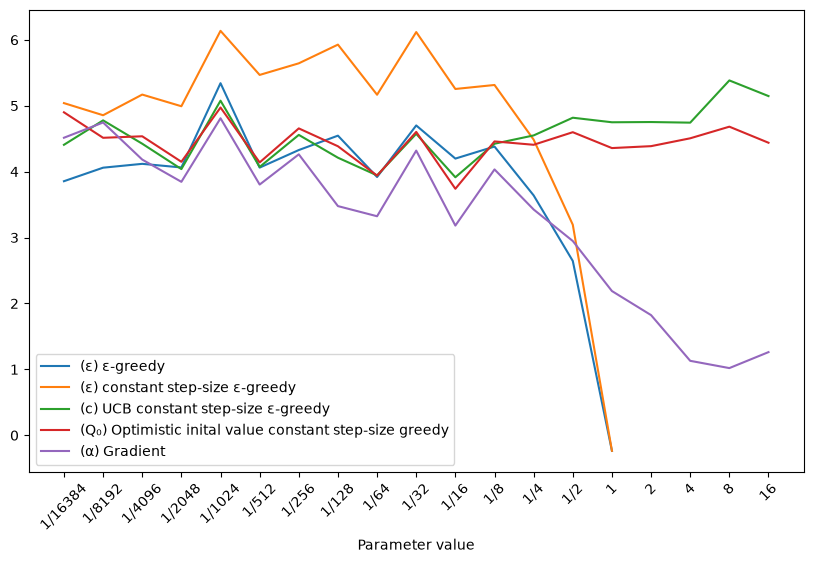

In [4]:
# Exercise 2.11: non-stationary parameter study
# Create a parameter study between ε-greedy, constant α-greedy, UCB, gradient bandit, and optimistic greedy methods on a non-stationary 10-armed bandit problem.
# Plot average reward using the last 100,000 steps of a 200,000 step run.
# Result:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
def bandit(action, true_rewards):
    reward = random.gauss(true_rewards[action],1)
    return reward

def egreedy(true_rewards, value_estimates, action_chosen, epsilon):
    if random.random() < epsilon:
        index = random.randint(0,9)            
        action = index
    else:  
        greediest_value = max(value_estimates)
        greedy_actions = np.where(value_estimates == greediest_value)[0]
        action = np.random.choice(greedy_actions)
    reward = bandit(action,true_rewards)
    action_chosen[action] += 1
    value_estimates[action] = value_estimates[action] + (1/action_chosen[action]) * (reward - value_estimates[action])
    return reward
            

def agreedy(true_rewards, value_estimates, action_chosen, epsilon, step_size):
    if random.random() < epsilon:
        index = random.randint(0,9)
        action = index
    else:
        greediest_value = max(value_estimates)
        greedy_actions = np.where(value_estimates == greediest_value)[0]
        action = np.random.choice(greedy_actions)
    reward = bandit(action,true_rewards)
    action_chosen[action] += 1
    value_estimates[action] = value_estimates[action] + step_size * (reward - value_estimates[action])
    return reward

def ucb(true_rewards, value_estimates, action_chosen, step_size, confidence, current_step, ucb_starting_choices):
    if current_step <= 10:
        action = ucb_starting_choices.pop(random.randint(0, len(ucb_starting_choices) - 1))
    else:
        estimate = value_estimates + confidence * np.sqrt(np.log(current_step) / action_chosen)
        action = np.argmax(estimate)
    reward = bandit(action,true_rewards)
    action_chosen[action] += 1
    value_estimates[action] = value_estimates[action] + step_size * (reward - value_estimates[action])
    return reward

def gradient(true_rewards, preferences, step_size, reward_sum, gradient_first_step, current_step):
    average_reward = reward_sum / current_step
    probs = np.exp(preferences) / np.sum(np.exp(preferences))
    probs /= np.sum(probs)
    if gradient_first_step:
        action = random.randint(0,9)
    else:
        actions = [0,1,2,3,4,5,6,7,8,9]
        action = np.random.choice(actions, p=probs)
    reward = bandit(action, true_rewards)
    preferences[action] = preferences[action] + step_size * (reward - average_reward) * (1 - ((np.exp(preferences[action])) / np.sum(np.exp(preferences))))
    preferences -= step_size * (reward - average_reward) * probs
    preferences[action] += step_size * (reward - average_reward) * probs[action]
    reward_sum += reward
    gradient_first_step = False
    return reward, gradient_first_step, reward_sum
 

def main():
    # initialize parameters in the parameter study  
    params = [1/16384, 1/8192, 1/4096, 1/2048, 1/1024, 1/512, 1/256, 1/128, 1/64, 1/32, 1/16, 1/8, 1/4, 1/2, 1, 2, 4, 8, 16] 
    gradient_alpha = epsilon = confidence = optimistic_initial = params[0]
    # initialize static parameters and numpy arrays
    steps = 200000
    runs = 50
    step_size_alpha = 0.1
    methods = ['egreedy', 'agreedy', 'ucb', 'optigreedy', 'gradient']
    parameter_reward = {m: [] for m in methods}
    # test range of parameters
    for i in range(len(params)):
        avg_rewards = {m: np.zeros(steps//2) for m in methods}
        
        # simulate runs
        for run in range(1, runs + 1):
            
            # initialize start of run variables
            true_rewards  = np.zeros(10)
             # note that though "optigreedy" is in val_est, it's not used
            optigreedy_val_est = np.full(10, optimistic_initial)
            val_est = {m: np.zeros(10) for m in methods}
            action_count = {m: np.zeros(10) for m in methods}
            run_rewards = {m: [] for m in methods}
            ucb_starting_choices = [0,1,2,3,4,5,6,7,8,9]
            gradient_first_step = True
            reward_sum = 0
            # simulate one run for each method
            for step in range(1,steps + 1):
                if epsilon <= 1:
                    egreedy_reward = egreedy(true_rewards, val_est['egreedy'], action_count['egreedy'], epsilon)
                    agreedy_reward = agreedy(true_rewards, val_est['agreedy'], action_count['agreedy'], epsilon, step_size_alpha)
                ucb_reward = ucb(true_rewards, val_est['ucb'], action_count['ucb'], step_size_alpha, confidence, step, ucb_starting_choices)
                optigreedy_reward = agreedy(true_rewards, optigreedy_val_est, action_count['optigreedy'], 0, step_size_alpha)
                gradient_reward, gradient_first_step, reward_sum = gradient(true_rewards, val_est['gradient'], gradient_alpha, reward_sum, gradient_first_step, step)
                if step > 100000:
                     run_rewards['egreedy'].append(egreedy_reward)
                     run_rewards['agreedy'].append(agreedy_reward)
                     run_rewards['ucb'].append(ucb_reward)
                     run_rewards['optigreedy'].append(optigreedy_reward)
                     run_rewards['gradient'].append(gradient_reward)
                # true rewards' random walk
                true_rewards += np.random.normal(0, 0.01, 10)
            if epsilon <= 1:
                avg_rewards['egreedy'] += run_rewards['egreedy']
                avg_rewards['agreedy'] += run_rewards['agreedy']

            avg_rewards['ucb'] += run_rewards['ucb']
            avg_rewards['optigreedy'] += run_rewards['optigreedy']
            avg_rewards['gradient'] += run_rewards['gradient']
        
        # get average rewards over runs
        for m in methods:
            avg_rewards[m] /= runs

        # get average reward of rewards
        avg_reward = {m: np.mean(avg_rewards[m]) for m in methods}
        
        if epsilon <= 1:
            parameter_reward['egreedy'].append(avg_reward['egreedy'])
            parameter_reward['agreedy'].append(avg_reward['agreedy'])

        else:
            parameter_reward['egreedy'].append(np.nan)           
            parameter_reward['agreedy'].append(np.nan)
        
        parameter_reward['ucb'].append(avg_reward['ucb'])
        parameter_reward['optigreedy'].append(avg_reward['optigreedy'])
        parameter_reward['gradient'].append(avg_reward['gradient'])

        print(avg_reward['egreedy'])
        
        # multiply all params by 2
        gradient_alpha, epsilon, confidence, optimistic_initial = [x * 2 for x in (gradient_alpha, epsilon, confidence, optimistic_initial)]

    # graphs
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(params, parameter_reward['egreedy'], label='(ε) ε-greedy')
    ax.plot(params, parameter_reward['agreedy'], label='(ε) constant step-size ε-greedy')
    ax.plot(params, parameter_reward['ucb'], label='(c) UCB constant step-size ε-greedy')
    ax.plot(params, parameter_reward['optigreedy'], label='(Q₀) Optimistic inital value constant step-size greedy')     
    ax.plot(params, parameter_reward['gradient'], label='(α) Gradient')




    #ax.plot(params, avg_rewards_ucb, label='UCB
    ax.set_xscale('log', base=2)
    ax.set_xlabel('Parameter value')
    ax.set_xticks(params)
    plt.xticks(rotation=45)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'1/{int(1/x)}' if x < 1 else str(int(x))))
    ax.legend()
    plt.show()

main()